# GAN-Based Image Generation on CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random, os, math, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm as SN
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torchvision.utils import make_grid
from scipy import linalg

SEED = 207
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 1. Data

In [2]:
BATCH = 64
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

tfm = T.Compose([T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
tfm_eval = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

train_ds = CIFAR10(root='./data', train=True, download=False, transform=tfm)
test_ds = CIFAR10(root='./data', train=False, download=False, transform=tfm_eval)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, pin_memory=True)
print(f'train: {len(train_ds)} | test: {len(test_ds)}')

c:\Users\\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: 50000 | test: 10000


In [3]:
# class distribution
counts = np.bincount([y for _,y in train_ds])
for c,n in zip(CLASSES, counts):
    print(f'{c:12s}: {n}')

airplane    : 5000
automobile  : 5000
bird        : 5000
cat         : 5000
deer        : 5000
dog         : 5000
frog        : 5000
horse       : 5000
ship        : 5000
truck       : 5000


## 3. Evaluation Utils

In [4]:
from torchvision.models import inception_v3, Inception_V3_Weights

class FIDScorer:
    def __init__(self, device=device):
        self.device = device
        net = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False)
        net.fc = nn.Identity()
        net.eval()
        self.net = net.to(device)
        self.up = nn.Upsample(size=(299,299), mode='bilinear', align_corners=False).to(device)

    @torch.no_grad()
    def get_feats(self, src, n=5000):
        feats = []
        if isinstance(src, torch.Tensor):
            src = DataLoader(torch.utils.data.TensorDataset(src), batch_size=BATCH)
            for (x,) in src:
                feats.append(self.net(self.up(x.to(self.device))).cpu())
                if sum(f.shape[0] for f in feats) >= n:
                    break
        else:
            for x,_ in src:
                feats.append(self.net(self.up(x.to(self.device))).cpu())
                if sum(f.shape[0] for f in feats) >= n:
                    break
        return torch.cat(feats)[:n].numpy()

    def fid(self, real_feats, fake_feats):
        mu1, si1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
        mu2, si2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
        diff = mu1 - mu2
        covmean,_ = linalg.sqrtm(si1@si2, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        return float(diff@diff + np.trace(si1+si2-2*covmean))

fid_scorer = FIDScorer()
real_feats = fid_scorer.get_feats(train_loader, n=50000)
print(f'real feats: {real_feats.shape}')

real feats: (50000, 2048)


In [ ]:
Z_DIM = 100  # pretrained weights latent dim

def evaluate_gan(G, n=5000, z_dim=Z_DIM, batch=128):
    G.eval()
    imgs = []
    with torch.no_grad():
        for _ in range(math.ceil(n/batch)):
            z = torch.randn(batch, Z_DIM, 1, 1, device=device)
            if z_dim < Z_DIM:
                z[:,Z_DIM-z_dim:] = 0
            imgs.append(G(z).cpu())
    imgs = torch.cat(imgs)[:n]
    score = fid_scorer.fid(real_feats, fid_scorer.get_feats(imgs))
    G.train()
    return score

def show_samples(G, z_dim=Z_DIM, n=64, title=''):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, z_dim, 1, 1, device=device)
        imgs = G(z).cpu()
    grid = make_grid(imgs*0.5+0.5)
    plt.figure(figsize=(10,10))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
    G.train()

## 4. Models

### 4.0 Pretrained Weights

Weights from [csinva/gan-vae-pretrained-pytorch](https://github.com/csinva/gan-vae-pretrained-pytorch) - DCGAN trained 200 epochs on CIFAR-10 (32x32). Architecture (nz=100, ngf=64, ndf=64) reconstructed exactly from source to ensure state_dict compatibility.

In [ ]:
_BASE = 'https://github.com/csinva/gan-vae-pretrained-pytorch/raw/master/cifar10_dcgan/weights'

def _fetch(url, dst):
    if not os.path.exists(dst):
        urllib.request.urlretrieve(url, dst)
    else:
        print(f'{dst} already cached')

_fetch(f'{_BASE}/netG_epoch_199.pth', 'pretrained_G.pth')
_fetch(f'{_BASE}/netD_epoch_199.pth', 'pretrained_D.pth')

### 4.1 DCGAN

`self.main` key matches the saved state_dict. 

In [4]:
class DCGANGenerator(nn.Module):
    def __init__(self, nz=Z_DIM, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(     nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2,     ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(    ngf,      nc, kernel_size=1, stride=1, padding=0, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.main(z)  # (B,3,32,32)

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 2, 2, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)  # (B,)

def weights_init(m):
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### 4.2 WGAN-GP

Generator reuses DCGAN architecture so pretrained G weights load directly. Critic drops sigmoid and BatchNorm per WGAN-GP paper.

In [5]:
class WGANCritic(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        cfgs = [(nc, ndf), (ndf, ndf*2), (ndf*2, ndf*4), (ndf*4, ndf*8)]
        layers = [l for ci,co in cfgs for l in [nn.Conv2d(ci, co, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True)]]
        layers += [nn.Conv2d(ndf*8, 1, 2, 2, 0, bias=False)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).view(-1)  # (B,)

def gradient_penalty(critic, real, fake, device=device):
    B = real.size(0)
    alpha = torch.rand(B,1,1,1, device=device)
    interp = (alpha*real + (1-alpha)*fake).requires_grad_(True)
    d_interp = critic(interp)
    grads = torch.autograd.grad(d_interp, interp, grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True)[0]
    return ((grads.view(B,-1).norm(2,dim=1)-1)**2).mean()

### 4.3 DCGAN + Spectral Normalization

Generator same as DCGAN (pretrained G loads). SN reparametrizes weights as `weight_orig`+`weight_u`/`weight_v` so pretrained D keys don't match - discriminator trains from scratch.

In [6]:
class SNGANDiscriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        cfgs = [(nc, ndf), (ndf, ndf*2), (ndf*2, ndf*4), (ndf*4, ndf*8)]
        layers = [l for ci,co in cfgs for l in [SN(nn.Conv2d(ci, co, 4, 2, 1, bias=False)), nn.LeakyReLU(0.2, True)]]
        layers += [SN(nn.Conv2d(ndf*8, 1, 2, 2, 0, bias=False)), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).view(-1)


## 5. Training

### 5.1 Training Utils

In [ ]:
def train_dcgan(G, D, loader, epochs=30, lr_g=2e-4, lr_d=2e-4, name='dcgan', z_dim=Z_DIM):
    G, D = G.to(device), D.to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5,0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5,0.999))
    crit = nn.BCELoss()
    hist = []
    for epoch in range(epochs):
        g_losses, d_losses = [], []
        for real,_ in loader:
            real = real.to(device)
            B = real.size(0)
            z = torch.randn(B, z_dim, 1, 1, device=device)
            fake = G(z).detach()
            real_lbl = torch.ones(B, device=device)*0.9  # label smoothing
            opt_d.zero_grad()
            d_loss = crit(D(real), real_lbl) + crit(D(fake), torch.zeros(B, device=device))
            d_loss.backward()
            opt_d.step()
            z = torch.randn(B, z_dim, 1, 1, device=device)
            opt_g.zero_grad()
            g_loss = crit(D(G(z)), torch.ones(B, device=device))
            g_loss.backward()
            opt_g.step()
            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
        fid = evaluate_gan(G, n=2000, z_dim=z_dim) if (epoch+1)%10==0 else None
        hist.append({'epoch':epoch+1,'g_loss':np.mean(g_losses),'d_loss':np.mean(d_losses),'fid':fid})
        if (epoch+1)%10==0:
            print(f'ep {epoch+1:3d} | g_loss: {hist[-1]["g_loss"]:.4f} | d_loss: {hist[-1]["d_loss"]:.4f} | FID: {fid:.2f}')
            torch.save(G.state_dict(), f'{name}_G.pt')
            torch.save(D.state_dict(), f'{name}_D.pt')
    return hist

def train_wgan(G, D, loader, epochs=30, lr=1e-4, n_crit=5, lam=10, name='wgan', z_dim=Z_DIM):
    G, D = G.to(device), D.to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0,0.9))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.0,0.9))
    hist = []
    data_iter = iter(loader)
    steps_per_ep = len(loader)//(n_crit+1)
    for epoch in range(epochs):
        g_losses, w_dists = [], []
        for _ in range(steps_per_ep):
            for _ in range(n_crit):  # n_crit=5 critic steps per generator step (WGAN-GP default)
                try:
                    real,_ = next(data_iter)
                except StopIteration:
                    data_iter = iter(loader)
                    real,_ = next(data_iter)
                real = real.to(device)
                B = real.size(0)
                z = torch.randn(B, z_dim, 1, 1, device=device)
                fake = G(z).detach()
                gp = gradient_penalty(D, real, fake)
                w = D(fake).mean() - D(real).mean()
                opt_d.zero_grad()
                (w + lam*gp).backward()  # lam=10 per paper
                opt_d.step()
                w_dists.append(-w.item())
            z = torch.randn(B, z_dim, 1, 1, device=device)
            opt_g.zero_grad()
            g_loss = -D(G(z)).mean()
            g_loss.backward()
            opt_g.step()
            g_losses.append(g_loss.item())
        fid = evaluate_gan(G, n=2000, z_dim=z_dim) if (epoch+1)%10==0 else None
        hist.append({'epoch':epoch+1,'g_loss':np.mean(g_losses),'w_dist':np.mean(w_dists),'fid':fid})
        if (epoch+1)%10==0:
            print(f'ep {epoch+1:3d} | g_loss: {hist[-1]["g_loss"]:.4f} | w_dist: {hist[-1]["w_dist"]:.4f} | FID: {fid:.2f}')
            torch.save(G.state_dict(), f'{name}_G.pt')
            torch.save(D.state_dict(), f'{name}_D.pt')
    return hist

### 5.2 DCGAN Baseline - load pretrained then fine-tune

In [7]:
print('DCGAN baseline')
print('-'*60)
dcgan_G = DCGANGenerator().to(device)
dcgan_D = DCGANDiscriminator().to(device)

# load csinva pretrained weights (nz=100, ngf=64, trained 200 epochs on CIFAR-10)
dcgan_G.load_state_dict(torch.load('./weights/pretrained_G.pth', map_location=device, weights_only=True))
dcgan_D.load_state_dict(torch.load('./weights/pretrained_D.pth', map_location=device, weights_only=True))
print(f'G params: {sum(p.numel() for p in dcgan_G.parameters())}')
print(f'D params: {sum(p.numel() for p in dcgan_D.parameters())}')

DCGAN baseline
------------------------------------------------------------
G params: 3573824
D params: 2759424


In [13]:
dcgan_hist = train_dcgan(dcgan_G, dcgan_D, train_loader, epochs=30, name='dcgan')

  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


ep  10 | g_loss: 3.6436 | d_loss: 0.5694 | FID: 38.04
ep  20 | g_loss: 3.8444 | d_loss: 0.5326 | FID: 38.29
ep  30 | g_loss: 3.8323 | d_loss: 0.5166 | FID: 39.11


In [8]:
dcgan_G.load_state_dict(torch.load('./weights/dcgan_G.pt', map_location=device, weights_only=True))
dcgan_D.load_state_dict(torch.load('./weights/dcgan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

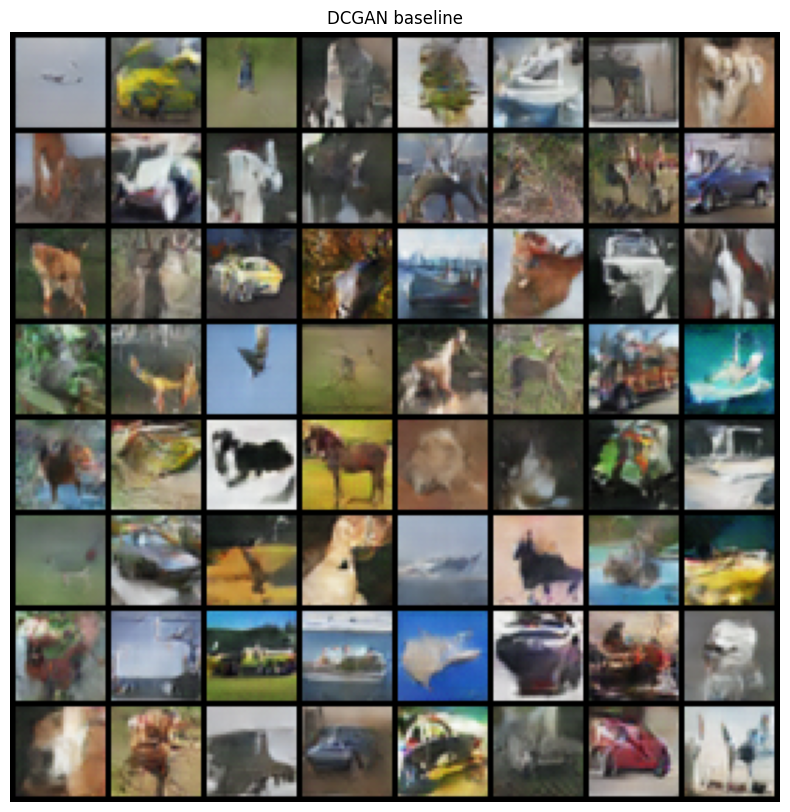

In [9]:
show_samples(dcgan_G, title='DCGAN baseline')

### 5.3 WGAN-GP - generator from pretrained, critic from scratch

In [11]:
print('WGAN-GP')
print('-'*60)
wgan_G = DCGANGenerator().to(device)
wgan_D = WGANCritic().to(device)

# load pretrained G; critic trains from scratch (different architecture)
wgan_G.load_state_dict(torch.load('./weights/pretrained_G.pth', map_location=device, weights_only=True))
wgan_D.apply(weights_init)

WGAN-GP
------------------------------------------------------------


WGANCritic(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(2, 2), stride=(2, 2), bias=False)
  )
)

In [17]:
wgan_hist = train_wgan(wgan_G, wgan_D, train_loader, epochs=30, name='wgan')

Local\Temp\ipykernel_7404\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


ep  10 | g_loss: -0.0225 | w_dist: 0.1564 | FID: 40.67
ep  20 | g_loss: 0.0852 | w_dist: 0.2096 | FID: 39.42
ep  30 | g_loss: 0.0645 | w_dist: 0.2254 | FID: 38.56


In [12]:
wgan_G.load_state_dict(torch.load('./weights/wgan_G.pt', map_location=device, weights_only=True))
wgan_D.load_state_dict(torch.load('./weights/wgan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

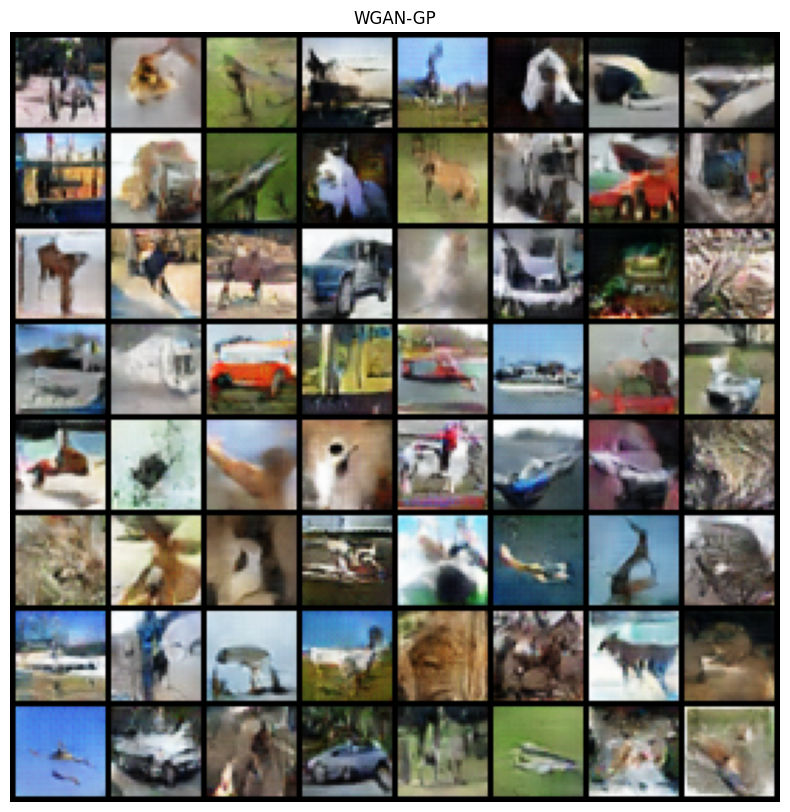

In [13]:
show_samples(wgan_G, title='WGAN-GP')

### 5.4 DCGAN + Spectral Norm - both from scratch

In [14]:
print('DCGAN + Spectral Norm')
print('-'*60)
sngan_G = DCGANGenerator().to(device)
sngan_D = SNGANDiscriminator().to(device)

sngan_G.apply(weights_init)
sngan_D.apply(weights_init)

DCGAN + Spectral Norm
------------------------------------------------------------


SNGANDiscriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (9): Sigmoid()
  )
)

In [14]:
sngan_hist = train_dcgan(sngan_G, sngan_D, train_loader, epochs=30, name='sngan')

C:\Users\\AppData\Local\Temp\ipykernel_2844\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


ep  10 | g_loss: 0.6924 | d_loss: 1.3798 | FID: 59.62
ep  20 | g_loss: 0.6935 | d_loss: 1.3782 | FID: 50.59
ep  30 | g_loss: 0.6929 | d_loss: 1.3770 | FID: 45.36


In [16]:
sngan_G.load_state_dict(torch.load('./weights/sngan_G.pt', map_location=device, weights_only=True))
sngan_D.load_state_dict(torch.load('./weights/sngan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

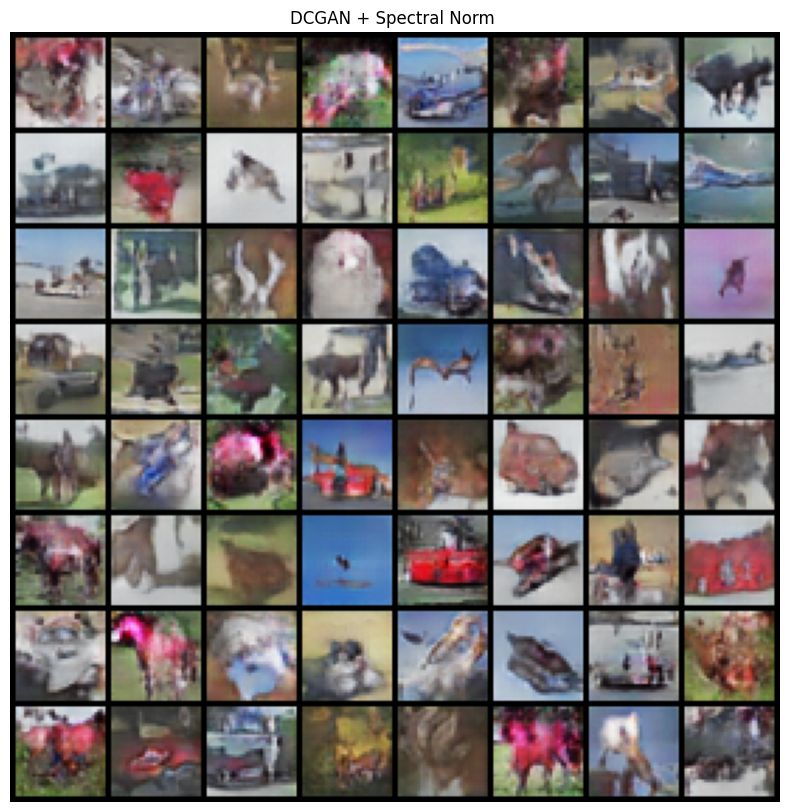

In [19]:
show_samples(sngan_G, title='DCGAN + Spectral Norm ')

## 6. Results

### 6.1 FID Comparison

In [26]:
results = {}
for name, G in [('DCGAN', dcgan_G), ('WGAN-GP', wgan_G), ('DCGAN+SN', sngan_G)]:
    fid = evaluate_gan(G, n=50000)
    results[name] = fid
    print(f'{name:15s} FID: {fid:.2f}')

Local\Temp\ipykernel_7404\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


DCGAN           FID: 30.61
WGAN-GP         FID: 29.97
DCGAN+SN        FID: 38.30


### 6.2 Training Curves

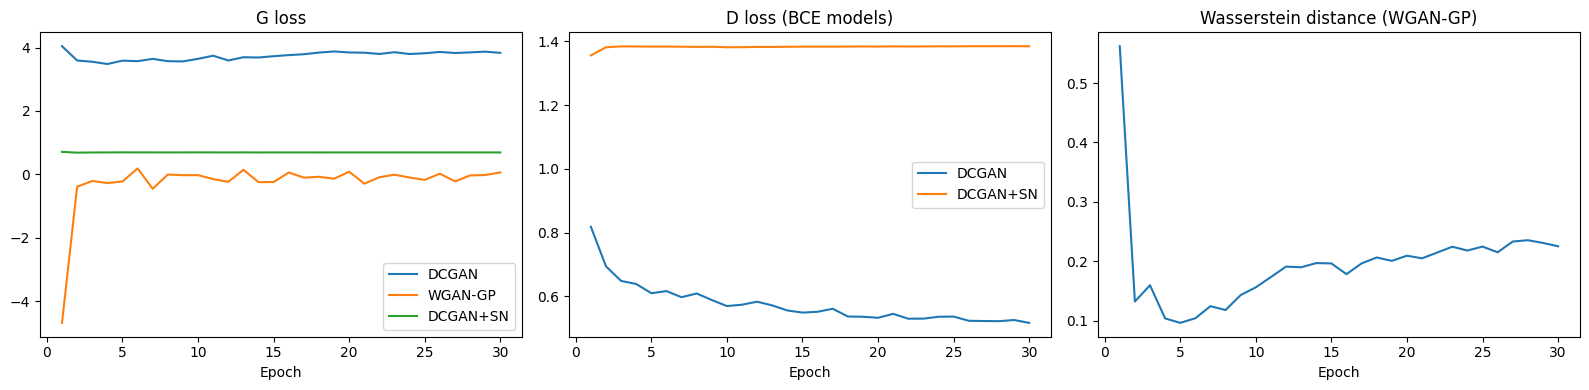

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

for hist, lbl in [(dcgan_hist,'DCGAN'),(wgan_hist,'WGAN-GP'),(sngan_hist,'DCGAN+SN')]:
    eps = [h['epoch'] for h in hist]
    axes[0].plot(eps, [h['g_loss'] for h in hist], label=lbl)
axes[0].set_title('G loss')
axes[0].legend()
axes[0].set_xlabel('Epoch')

for hist, lbl in [(dcgan_hist,'DCGAN'),(sngan_hist,'DCGAN+SN')]:
    eps = [h['epoch'] for h in hist]
    axes[1].plot(eps, [h['d_loss'] for h in hist], label=lbl)
axes[1].set_title('D loss (BCE models)')
axes[1].legend()
axes[1].set_xlabel('Epoch')

eps = [h['epoch'] for h in wgan_hist]
axes[2].plot(eps, [h['w_dist'] for h in wgan_hist])
axes[2].set_title('Wasserstein distance (WGAN-GP)')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 7. Ablations

In [ ]:
print('WGAN-GP Ablation: critic ratio 2:1')
print('-'*60)
wgan_ab_G = DCGANGenerator().to(device)
wgan_ab_D = WGANCritic().to(device)
wgan_ab_G.load_state_dict(torch.load('./weights/pretrained_G.pth', map_location=device, weights_only=True))
wgan_ab_D.apply(weights_init)
wgan_ab_hist = train_wgan(wgan_ab_G, wgan_ab_D, train_loader,n_crit=2, epochs=30, name='wgan_ab')

WGAN-GP Ablation: critic ratio 2:1
------------------------------------------------------------


Local\Temp\ipykernel_7404\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


ep  10 | g_loss: -0.0227 | w_dist: 0.0189 | FID: 43.22
ep  20 | g_loss: -0.0089 | w_dist: 0.0613 | FID: 45.06
ep  30 | g_loss: 0.0530 | w_dist: 0.0703 | FID: 50.10


In [21]:
print(f'FID: {evaluate_gan(wgan_ab_G,n=50000):.2f}')

C:\Users\\AppData\Local\Temp\ipykernel_2844\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


FID: 34.93


In [ ]:
print('Latent Space Dimensionality Ablation')
print('-'*60)
print(f'Reduced z_dim=50:')
for name, G in [('DCGAN', dcgan_G), ('WGAN-GP', wgan_G), ('DCGAN+SN', sngan_G)]:
    fid = evaluate_gan(G, n=5000, z_dim=50)
    print(f'{name:15s} FID: {fid:.2f}')

Latent Space Dimensionality Ablation
------------------------------------------------------------
Reduced z_dim=50:


Local\Temp\ipykernel_7404\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


DCGAN           FID: 97.09
WGAN-GP         FID: 109.69
DCGAN+SN        FID: 165.02


In [42]:
for name, G in [('DCGAN', dcgan_G), ('WGAN-GP', wgan_G), ('DCGAN+SN', sngan_G)]:
    fid = evaluate_gan(G, n=5000, z_dim=70)
    print(f'{name:15s} FID: {fid:.2f}')

Local\Temp\ipykernel_7404\4222145595.py:32: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean,_ = linalg.sqrtm(si1@si2, disp=False)


DCGAN           FID: 201.31
WGAN-GP         FID: 240.20
DCGAN+SN        FID: 293.69


## 8. Analysis

### 8.1  Diversity

In [ ]:
@torch.no_grad()
def diversity_score(G, z_dim=Z_DIM, batch=128):
    G.eval()
    imgs = []
    for _ in range(math.ceil(256/batch)):
        z = torch.randn(batch, z_dim, 1, 1, device=device)
        imgs.append(G(z).cpu())
    imgs = torch.cat(imgs).view(256,-1).float()
    a, b = imgs[:128], imgs[128:]
    return (a-b).norm(dim=1).mean().item()

print('Batch diversity (128 paired differences) :')
print('-'*60)
for name, G in [('DCGAN', dcgan_G), ('WGAN-GP', wgan_G), ('DCGAN+SN', sngan_G)]:
    print(f'{name:15s}: {diversity_score(G):.4f}')

Batch diversity :
------------------------------------------------------------
DCGAN          : 31.6683
WGAN-GP        : 38.1527
DCGAN+SN       : 28.0668


### 8.2 Latent Space Interpolation

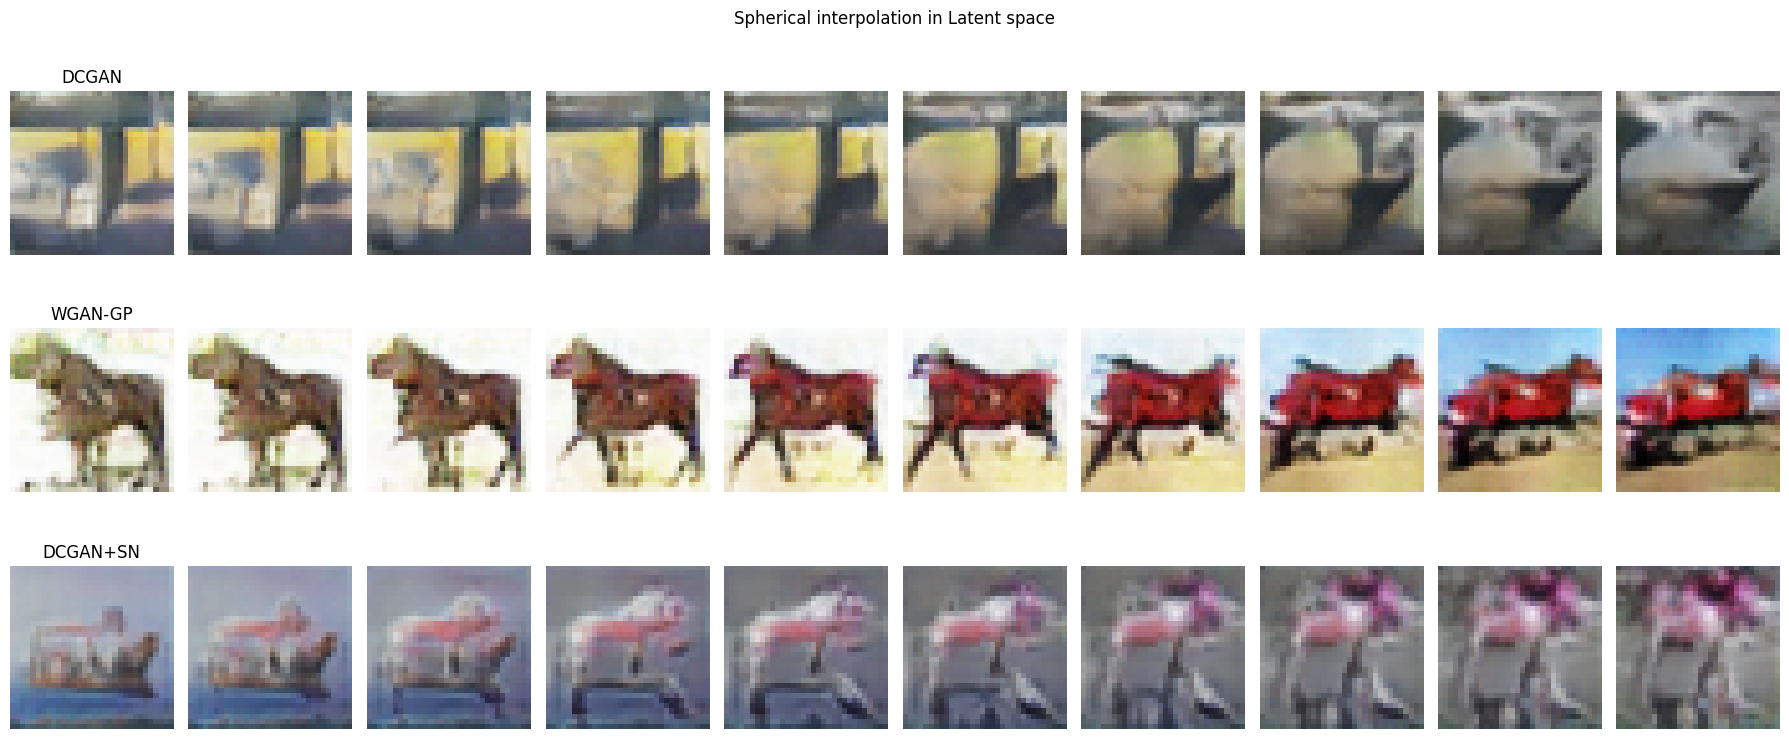

In [116]:
def slerp(z1, z2, t):
    # z1, z2: (1, nz, 1, 1)
    z1f, z2f = z1.view(-1), z2.view(-1)
    omega = torch.acos((z1f/z1f.norm() * z2f/z2f.norm()).sum().clamp(-1,1))
    if omega.abs() < 1e-6:
        return (1-t)*z1 + t*z2
    return (torch.sin((1-t)*omega)/torch.sin(omega))*z1 + (torch.sin(t*omega)/torch.sin(omega))*z2

def interpolate(G, steps=10, z_dim=Z_DIM):
    G.eval()
    z1 = torch.randn(1, z_dim, 1, 1, device=device)
    z2 = torch.randn(1, z_dim, 1, 1, device=device)
    imgs = []
    with torch.no_grad():
        for t in np.linspace(0,1,steps):
            imgs.append(G(slerp(z1, z2, t)).cpu()[0])
    G.train()
    return imgs

all_models = [('DCGAN',dcgan_G),('WGAN-GP',wgan_G),('DCGAN+SN',sngan_G)]
fig, axes = plt.subplots(3, 10, figsize=(18,8))
for i,(name,G) in enumerate(all_models):
    axes[i][0].set_title(name)
    for j,img in enumerate(interpolate(G, steps=10)):
        axes[i][j].imshow(img.permute(1,2,0).numpy()*0.5+0.5)
        axes[i][j].axis('off')
plt.suptitle('Spherical interpolation in Latent space')
plt.tight_layout()
plt.show()